<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

# Preamble

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr
import pickle

from sklearn.preprocessing import LabelEncoder

# Load Data

In [2]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../../data/08-Treenet-GROmeteo_1h_ALL_clean.csv')
df.head()

/home/mirko/pyEnv/deepTree/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (2,3) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,ts,station,subplot,tree,species,GRO,GRO.yr,GRO.A,GRO.rel,dGRO.yr,...,rh,vpd,rad,swp,total_precip,year,month,doy,hour,week
0,2014-01-01T00:00:00Z,Alvaneu,1552,N1,Pinus sylvestris,NaN,NaN,NaN,NaN,NaN,...,58.16667,0.220598,0.0,-10.324773,0.0,2014,1,1,0,1
1,2014-01-01T01:00:00Z,Alvaneu,1552,N1,Pinus sylvestris,NaN,NaN,NaN,NaN,NaN,...,59.16667,0.215325,0.0,-10.325957,0.0,2014,1,1,1,1
2,2014-01-01T02:00:00Z,Alvaneu,1552,N1,Pinus sylvestris,NaN,NaN,NaN,NaN,NaN,...,62.25000,0.199066,0.0,-10.324773,0.0,2014,1,1,2,1
3,2014-01-01T03:00:00Z,Alvaneu,1552,N1,Pinus sylvestris,NaN,NaN,NaN,NaN,NaN,...,61.66667,0.209746,0.0,-10.323579,0.0,2014,1,1,3,1
4,2014-01-01T04:00:00Z,Alvaneu,1552,N1,Pinus sylvestris,NaN,NaN,NaN,NaN,NaN,...,63.00000,0.202451,0.0,-10.324773,0.0,2014,1,1,4,1


# Clean the Data

In [8]:
 ## to fix some types inconsistencies in columns of the data
def clean_int(s):
    try: 
        int(s)
        return int(s)
    except ValueError:
        return s

In [9]:
df['subplot'] = df['subplot'].apply(clean_int)
df['tree'] = df['tree'].apply(clean_int)
df = df.dropna(subset=['GRO'])
df['subplot'] = df['subplot'].fillna('nan') #replace NaN by 'nan'
df['id'] = df.groupby(['station','subplot','tree']).grouper.group_info[0]
df['ts'] = pd.to_datetime(df['ts'])
len(df[['station','subplot','tree']].drop_duplicates())

190

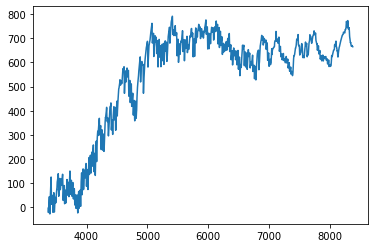

In [6]:
plt.plot(df['GRO'].iloc[0:5000])

# Jump size distribution

# Make Training Examples

In [10]:
## drop na and select only some features
df = df.dropna(subset=['GRO','temp','rh','vpd','swp','rad','total_precip'])
df_select = df[['ts','id', 'species','GRO','temp','rh','vpd','swp','total_precip','rad','hour','month']]
days = 30
X = []
y = []
n_id = max(df['id']) + 1

## loop over tree ids
for id_num in range(n_id):
    df_id = df_select.loc[df_select['id']==id_num]
    n_examples = len(df_id) // (days*24)
    data_X = df_id[['id','ts','species','temp','rh','vpd','swp','total_precip','rad','hour','month']].to_numpy()
    data_y = df_id[['GRO']].to_numpy()

    days_start_indexes = np.where(df_id['hour']==0)[0]
    dates = df_id['ts'].to_numpy()

    
    ## find good chunks of N days. [ML] Selection of intervals that have well defined consecutive hourly values for N days in all channles. For this reason the hour is used.
    i = 0
    while (i+days) < len(days_start_indexes):
        delta = dates[days_start_indexes[i+days]] - dates[days_start_indexes[i]]
        #hours_duration = delta.astype('timedelta64[h]').astype(int)
        hours_duration = pd.to_timedelta([delta]).astype('timedelta64[h]').astype(int)
        if (hours_duration == days*24) and (days_start_indexes[i+days]-days_start_indexes[i]==days*24): #we have exactly N full days, should check with time instead (a whole day could be skipped)
            data_X_series = data_X[days_start_indexes[i]:days_start_indexes[i+days]]
            data_y_series = data_y[days_start_indexes[i]:days_start_indexes[i+days]]
            X.append(data_X_series)
            y.append(data_y_series)
            i += days
        else:
            i += 1
    print(f'\r{id_num}/{n_id-1}',end="")

189/189

# Remove Small Classes

In [11]:
## remove minority classes
y = np.array(y).reshape(-1, days*24)
X = np.array(X)
mask = (X[:,0,2] == 'Sorbus aria') | (X[:,0,2] == 'Larix decidua') | (X[:,0,2] == 'Quercus robur') #species is at column 2 (start counting from 0)
X = np.array(X)[~mask,:,:]
y = y[~mask]

## encode classes into ints
lb = LabelEncoder()
X[:,:,2] = lb.fit_transform(np.array(X[:,0,2]).reshape(-1)).reshape(-1,1) #species is at colum 2 (start counting from 0)

# Save the Data

In [9]:
## save the data, use them with the LSTM notebook
with open(f'../../results/cleaned_data/X_{days}_days_regression.pickle', 'wb') as handle:
    pickle.dump(X, handle)

with open(f'../../results/cleaned_data/y_{days}_days_regression.pickle', 'wb') as handle:
    pickle.dump(y, handle)
    
print(f'{len(X)} chunks')

6943 chunks


In [11]:
X.shape

(6943, 720, 11)

In [13]:
X[0][:,9]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7, 8,
       9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1, 2,
       3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
       21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
       11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
       13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7,
       8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1,
       2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 